Online Shoppers Intension Prediction

In [1]:
# ============================================
# 1. DATA LOADING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

data = pd.read_csv("online_shoppers_intention.csv")
print("Shape:", data.shape)
data.info()
print(data.head())


Shape: (12330, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  Tra

In [2]:
# ============================================
# 2. DATA CLEANING
# ============================================

print("\nMissing values:\n", data.isnull().sum())

data = data.drop_duplicates()
data["Weekend"] = data["Weekend"].astype(int)
data["Revenue"] = data["Revenue"].astype(int)

month_mapping = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "June": 6,
    "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12,
}
data["Month"] = data["Month"].map(month_mapping)

print("\nAfter cleaning:")
data.info()



Missing values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

After cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4

       Administrative  Administrative_Duration  Informational  \
count    12205.000000             12205.000000   12205.000000   
mean         2.338878                81.646331       0.508726   
std          3.330436               177.491845       1.275617   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 9.000000       0.000000   
75%          4.000000                94.700000       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12205.000000    12205.000000             12205.000000   
mean                34.825454       32.045637              1206.982457   
std                141.424807       44.593649              1919.601400   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        8.00000

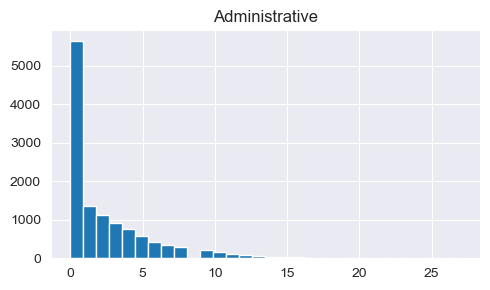

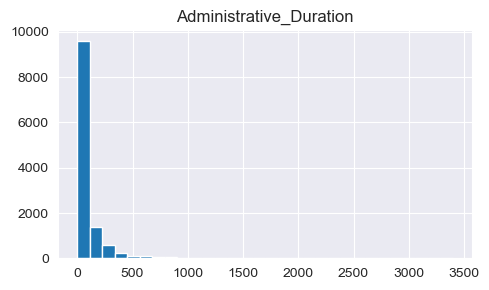

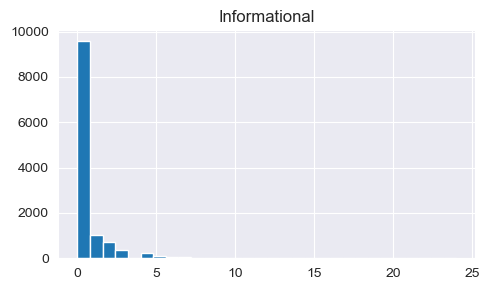

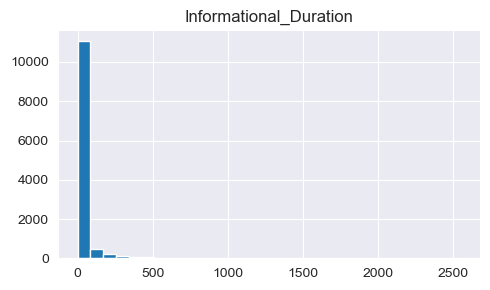

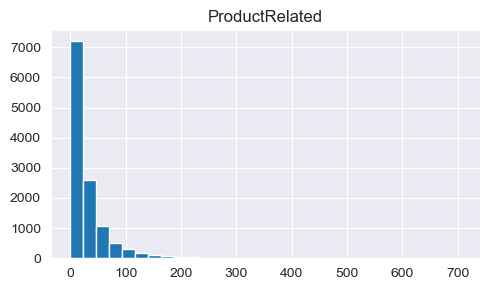

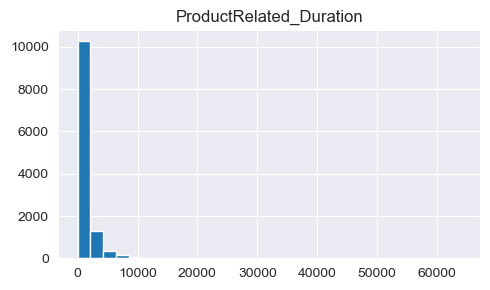

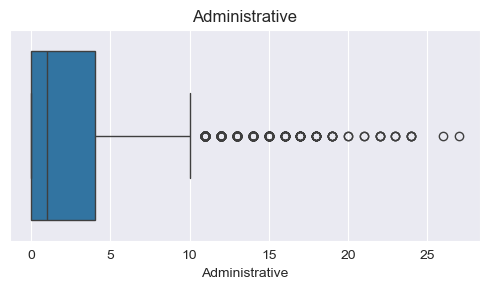

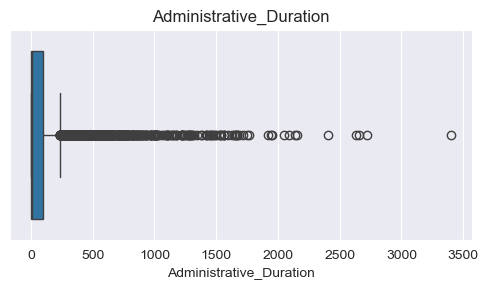

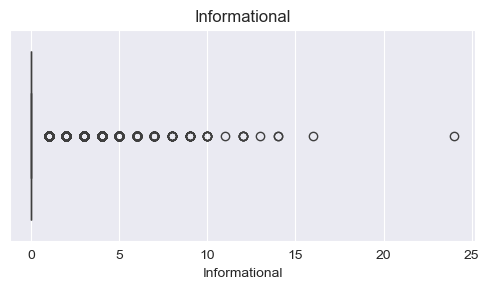

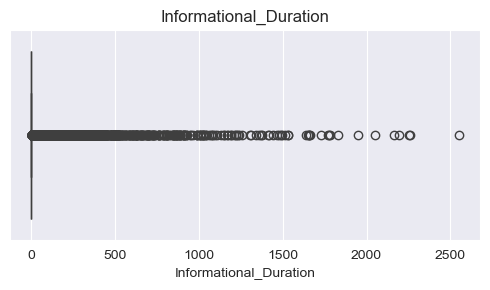

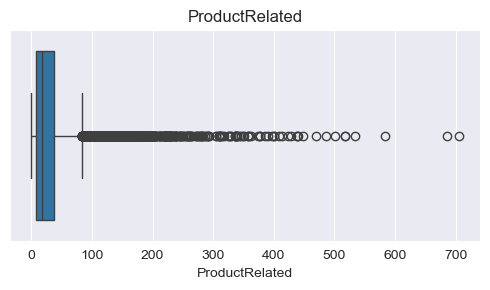

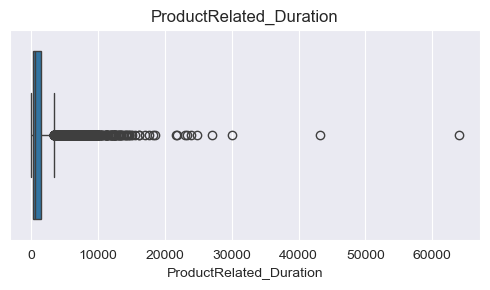

In [3]:
# ============================================
# 3. EXPLORATORY ANALYSIS
# ============================================

print(data.describe())

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("Revenue")

# Histograms
for col in numeric_cols[:6]:
    plt.figure(figsize=(5, 3))
    plt.hist(data[col], bins=30)
    plt.title(col)
    plt.tight_layout()
    plt.show()

# Boxplots
for col in numeric_cols[:6]:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()


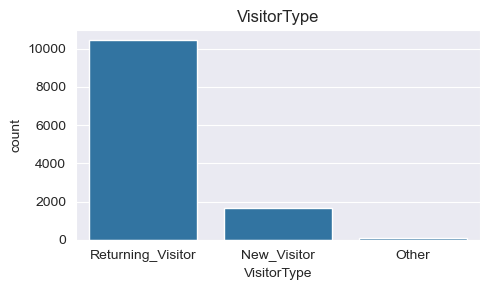

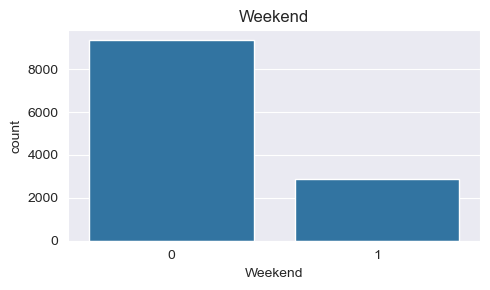

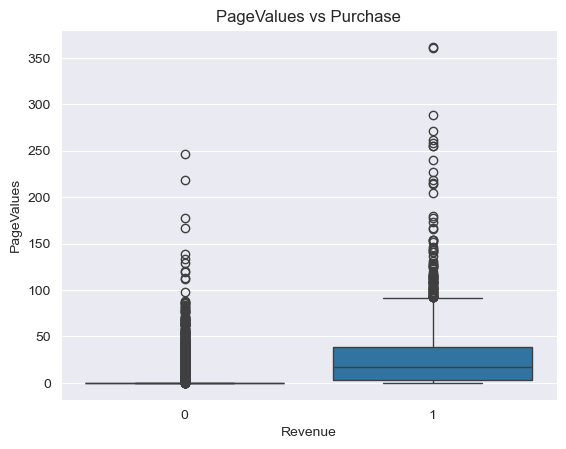

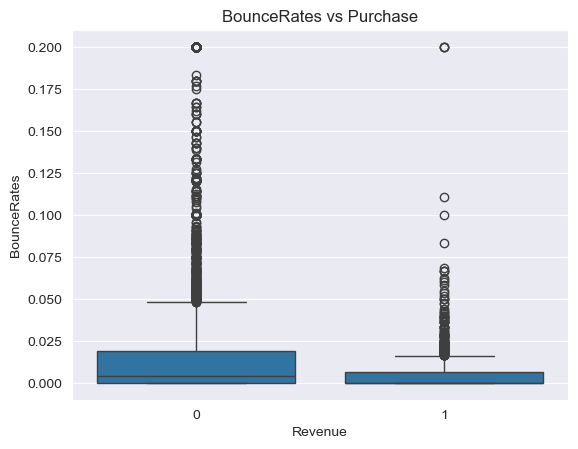

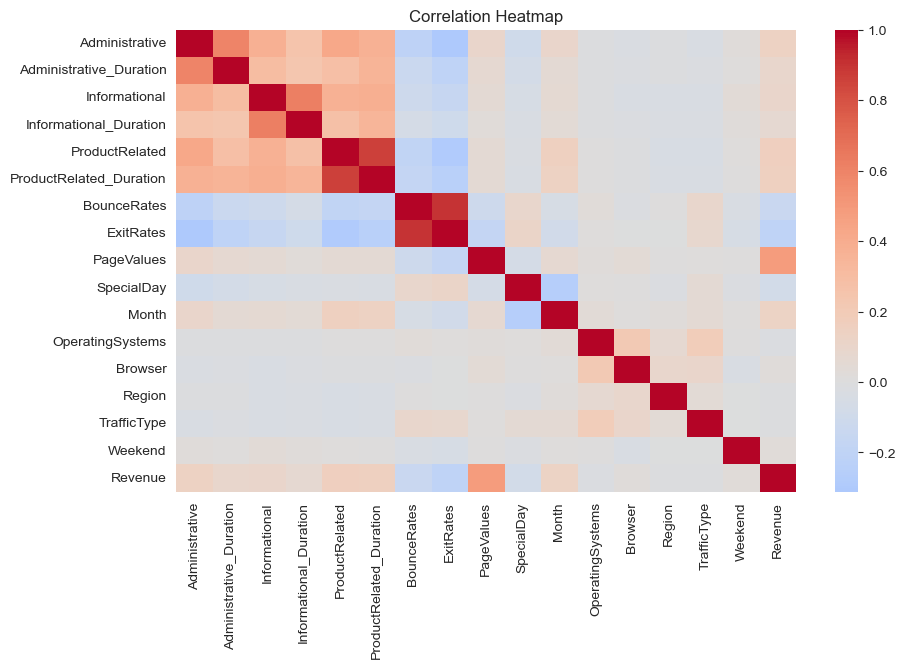

In [4]:
category_cols = ["VisitorType", "Weekend"]
for col in category_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, data=data)
    plt.title(col)
    plt.tight_layout()
    plt.show()

sns.boxplot(x="Revenue", y="PageValues", data=data)
plt.title("PageValues vs Purchase")
plt.show()

sns.boxplot(x="Revenue", y="BounceRates", data=data)
plt.title("BounceRates vs Purchase")
plt.show()

numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [5]:
# ============================================
# 4. FEATURE ENGINEERING
# ============================================

data["TotalTimeSpent"] = (
    data["Administrative_Duration"]
    + data["Informational_Duration"]
    + data["ProductRelated_Duration"]
)

features = data.drop(columns=["Revenue"])
labels = data["Revenue"]

numeric_features = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = features.select_dtypes(exclude=[np.number]).columns.tolist()

num_transform = Pipeline([("scale", StandardScaler())])
cat_transform = Pipeline([("encode", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(
    [
        ("num", num_transform, numeric_features),
        ("cat", cat_transform, categorical_features),
    ]
)



===== Logistic Regression =====
Accuracy: 0.8713641950020483
Precision: 0.5656370656370656
Recall: 0.7670157068062827
AUC: 0.9041775476836466
[[1834  225]
 [  89  293]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2059
           1       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



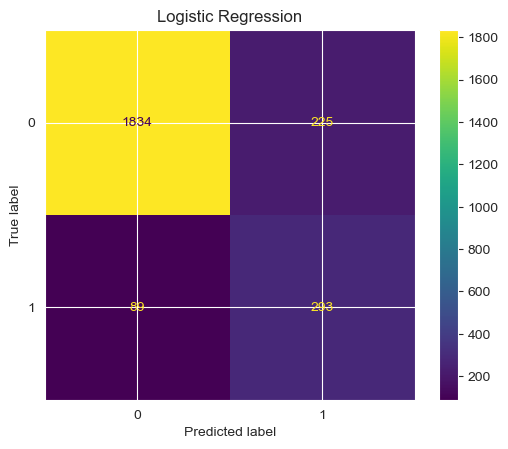


===== Decision Tree =====
Accuracy: 0.8562064727570667
Precision: 0.5257048092868989
Recall: 0.8298429319371727
AUC: 0.9167414670365577
[[1773  286]
 [  65  317]]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      2059
           1       0.53      0.83      0.64       382

    accuracy                           0.86      2441
   macro avg       0.75      0.85      0.78      2441
weighted avg       0.90      0.86      0.87      2441



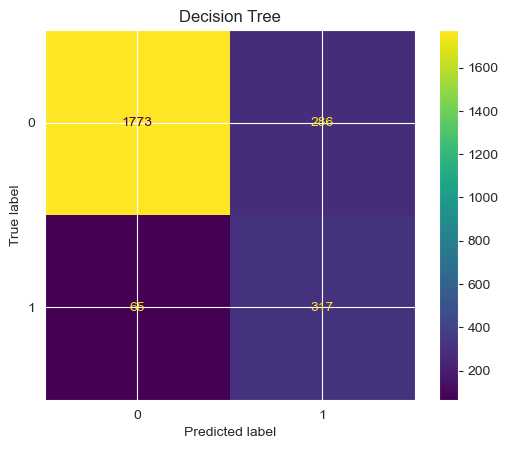

['purchase_model.pkl']

In [6]:
# ============================================
# 5. MODEL TRAINING
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.20, random_state=42, stratify=labels
)

logistic_model = Pipeline(
    [
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

tree_model = Pipeline(
    [
        ("prep", preprocess),
        (
            "model",
            DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
        ),
    ]
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
}

performance = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)                       # how many correct predictions
    prec = precision_score(y_test, predictions)                     # gives not many false alarms
    rec = recall_score(y_test, predictions)                         # out of all purchasers, how many were correctly represented
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])  # how well it separates buyers from non-buyers

    performance[name] = [acc, prec, rec, auc]

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("AUC:", auc)
    print(confusion_matrix(y_test, predictions))
    print(classification_report(y_test, predictions))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(name)
    plt.show()

joblib.dump(logistic_model, "purchase_model.pkl")


                     Accuracy  Precision    Recall       AUC
Logistic Regression  0.871364   0.565637  0.767016  0.904178
Decision Tree        0.856206   0.525705  0.829843  0.916741


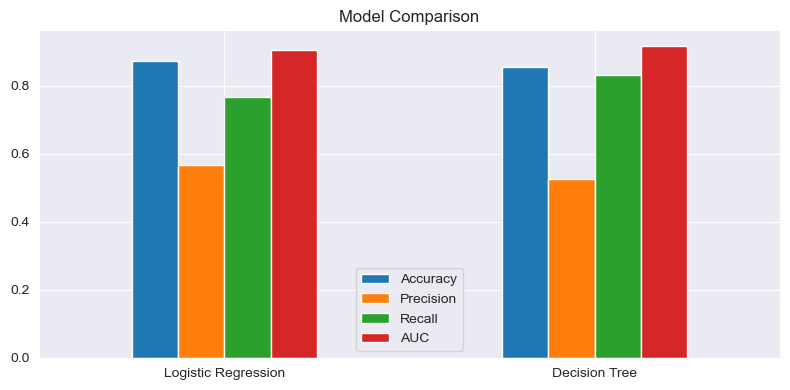

In [7]:
# ============================================
# 6. MODEL COMPARISON
# ============================================

perf_df = pd.DataFrame(performance, index=["Accuracy", "Precision", "Recall", "AUC"]).T
print(perf_df)

perf_df.plot(kind="bar", figsize=(8, 4))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


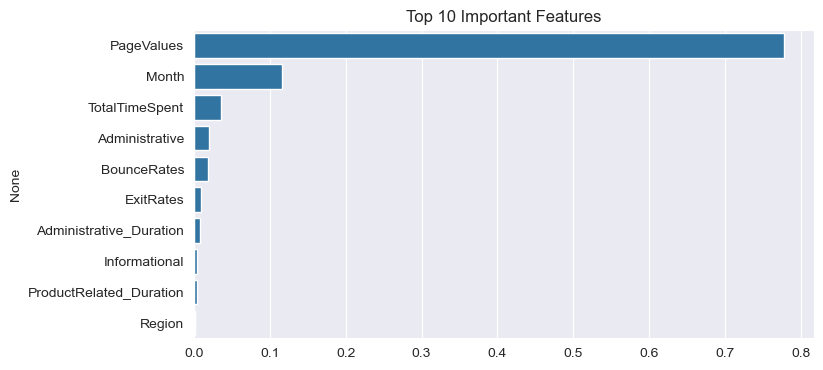

In [9]:
# ============================================
# 7. FEATURE IMPORTANCE
# ============================================

tree_clf = tree_model.named_steps["model"]
encoded_feature_names = numeric_features + list(
    tree_model.named_steps["prep"]
    .named_transformers_["cat"]
    .named_steps["encode"]
    .get_feature_names_out(categorical_features)
)

importances = tree_clf.feature_importances_
top_features = (
    pd.Series(importances, index=encoded_feature_names)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Important Features")
plt.show()
